https://stackoverflow.com/questions/74141355/dimensionality-reduction-autoencoder-pytorch

#### Imports

In [1]:
import time
import copy
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

Current device: cuda


#### Path definition and file inspection

In [2]:
# paths
root = Path("../AMLEC-1/rtm_emulation")

train_file_a_500 = root / "scenarioA" / "train" / "train500.h5"
train_file_a_2000 = root / "scenarioA" / "train" / "train2000.h5"
train_file_a_10000 = root / "scenarioA" / "train" / "train10000.h5"
test_file_a_interp = root / "scenarioA" / "reference" / "refInterp.csv"
test_file_a_extrap = root / "scenarioA" / "reference" / "refExtrap.csv"

train_file_b_500 = root / "scenarioB" / "train" / "train500.h5"
train_file_b_2000 = root / "scenarioB" / "train" / "train2000.h5"
test_file_b_interp = root / "scenarioB" / "reference" / "refInterp.csv"
test_file_b_extrap = root / "scenarioB" / "reference" / "refExtrap.csv"

current_train_file = train_file_a_500
current_test_file = test_file_a_interp

In [3]:
# inspect metadata of a train_file
param_names = []
function_names = []

with h5py.File(current_train_file, "r") as f:
    print("Keys in train_file:", list(f.keys()))
    print("\nAttributes in LUTheader (inputs):")
    for key, value in f["LUTheader"].attrs.items():
        print(f"  {key}: {value}")
    print("\nAttributes in train_file (outputs):")
    for key, value in f.attrs.items():
        print(f"  {key}: {value}")
    print("\nLUTheader shape:", f["LUTheader"].shape)
    print("LUTdata shape:", f["LUTdata"].shape)
    print("wvl shape:", f["wvl"].shape)

    for param in f["LUTheader"].attrs["varnames"].split(","):
        param_names.append(param.strip())

    for func in f.attrs["outnames"].split(","):
        function_names.append(func.strip())

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


#### Dataset loading and exploration

In [4]:
def load_train_h5(path):
    """
    Load a training .h5 file
    - inputs: path to the .h5 file
    - outputs: numpy array X (inputs) of shape (n_samples, n_features), numpy array Y (outputs) of shape (n_samples, n_outputs), numpy array wvl (wavelengths)
    """
    with h5py.File(path, "r") as f:
        Y = f["LUTdata"][:]      # outputs
        X = f["LUTheader"][:]    # inputs
        wvl = f["wvl"][:]        # wavelengths

    return X, Y, wvl

def load_test_csv(path):
    """
    Load a test .csv file
    - inputs: path to the .csv file
    - outputs: numpy array X (inputs) of shape (n_samples, n_features)
    """
    df = pd.read_csv(path, header=None)
    X = df.to_numpy()
    return X.T

# load data
X_train, Y_train, wavelengths = load_train_h5(current_train_file)
X_test = load_test_csv(current_test_file)

# inspect shapes
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
wavelengths = wavelengths.squeeze()
print("wavelengths:", wavelengths.shape)

X_train: (500, 9)
Y_train: (500, 25230)
X_test: (10000, 9)
wavelengths: (4205,)


For each sample:
- Inputs: 9 physical parameters (aerosols, gases, geometry, etc.)
- Outputs: 6 different radiative quantities (25230 / 4205) each evaluated over 4205 wavelengths

In [5]:
# print start of X_train
print("X_train (first 5 rows):\n", X_train[:5])
print()

# print basic stats of X_train
print("X_train stats:")
print("  min:", X_train.min(axis=0))
print("  max:", X_train.max(axis=0))
print("  mean:", X_train.mean(axis=0))
print("  std:", X_train.std(axis=0))
print()

# print basic stats of wavelengths
print("wavelengths stats:")
print("  min:", wavelengths.min())
print("  max:", wavelengths.max())
print("  average step:", np.diff(wavelengths).mean())

X_train (first 5 rows):
 [[  0.3277   3.1157   0.345    0.7131   0.5288   0.8954  19.7791   7.7608 108.5301]
 [  0.3934   1.9633   0.1254   0.6778   1.076    0.9024  13.9765   0.7065  57.5871]
 [  0.277    3.3399   0.3508   0.7798   0.5656   0.8813  22.8422   8.8415  86.0363]
 [  0.3872   2.9762   0.2018   0.6871   0.7028   0.895   41.9614   7.6079 102.0078]
 [  0.3122   3.1903   0.1551   0.7968   0.7071   0.8519  19.9584   1.0314 145.9431]]

X_train stats:
  min: [ 0.2503  0.701   0.1007  0.6002  0.5     0.8501 10.0422  0.0239  0.0474]
  max: [  0.3999   3.4994   0.4992   0.7997   1.6998   0.9498  59.9118  14.9793 179.9885]
  mean: [ 0.325   2.1     0.3     0.7     1.1     0.9    35.0001  7.4998 90.0019]
  std: [ 0.0433  0.8084  0.1155  0.0577  0.3464  0.0289 14.433   4.3303 51.9564]

wavelengths stats:
  min: 399.8400639744102
  max: 2506.2656641604012
  average step: 0.5010527117473813


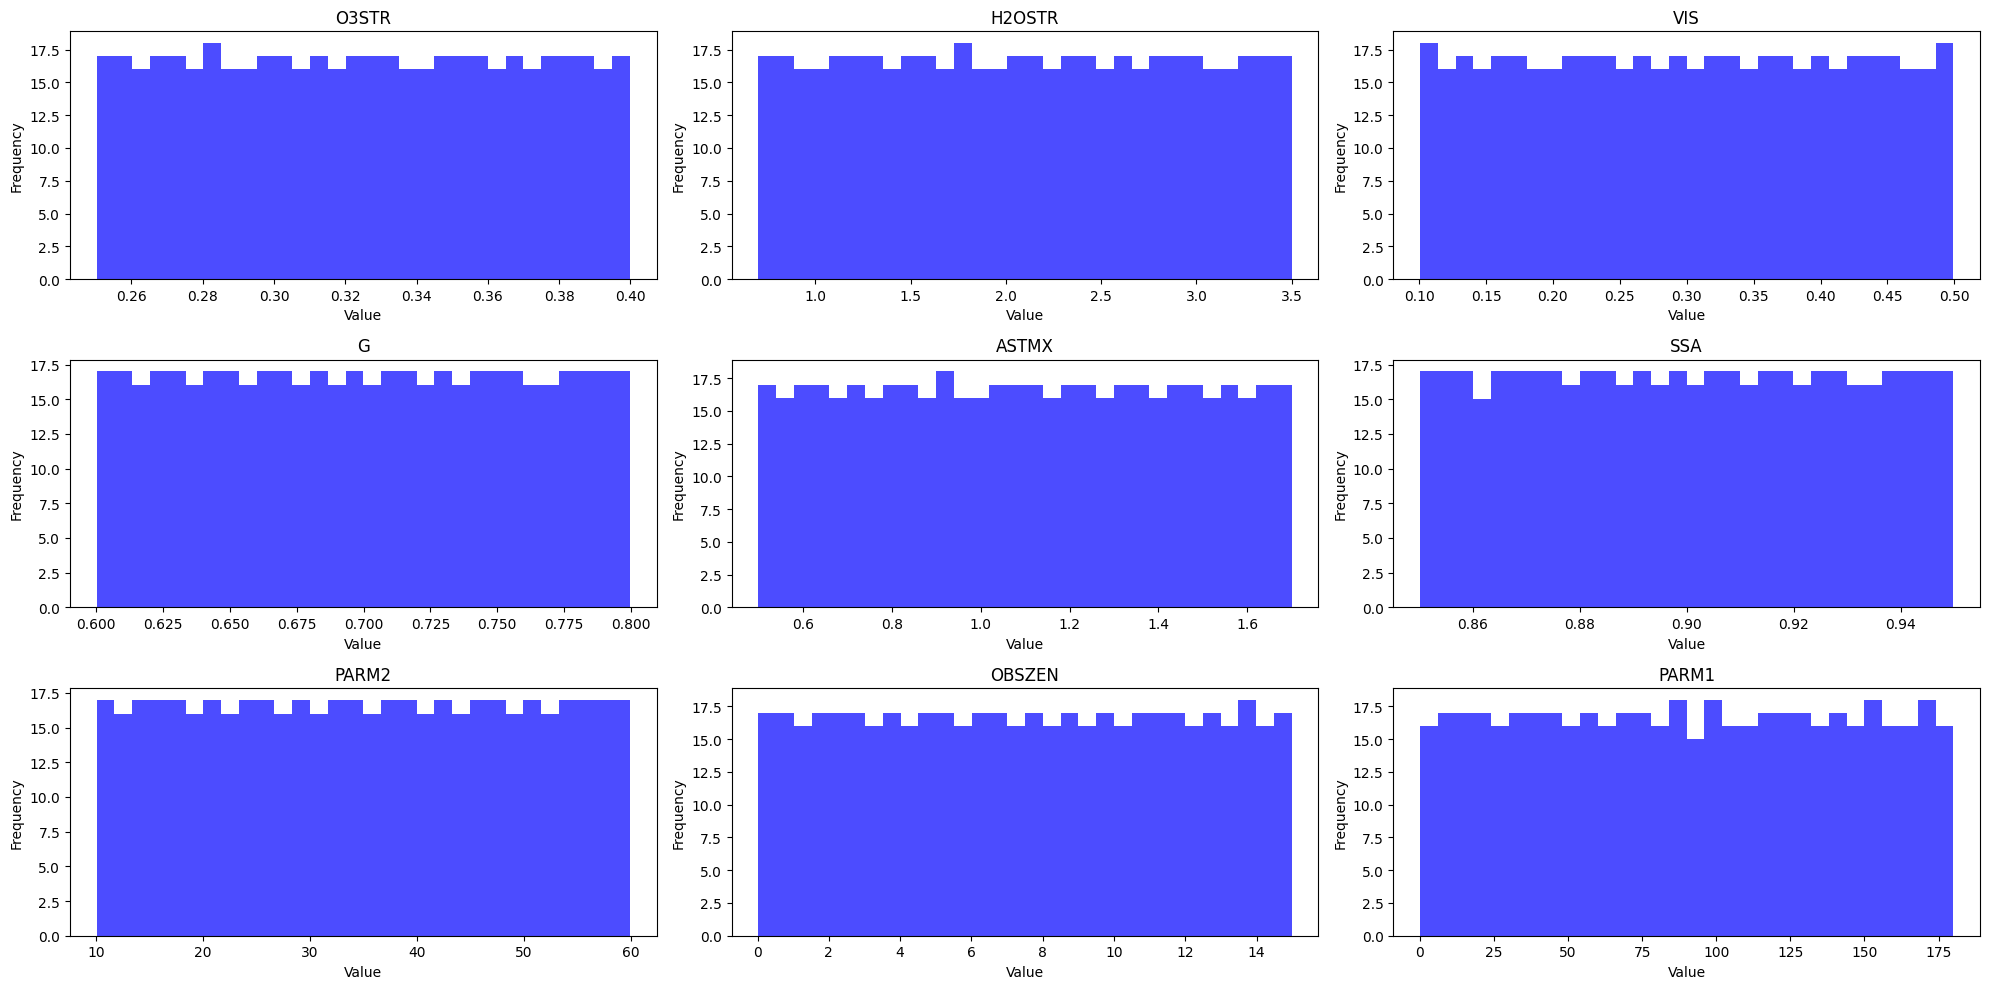

In [6]:
# visualize distribution of all 9 input parameters
plt.figure(figsize=(20, 10))
for i in range(X_train.shape[1]):
    plt.subplot(3, 3, i+1)
    plt.hist(X_train[:, i], bins=30, color="blue", alpha=0.7)
    plt.title(param_names[i])
    plt.xlabel("Value")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

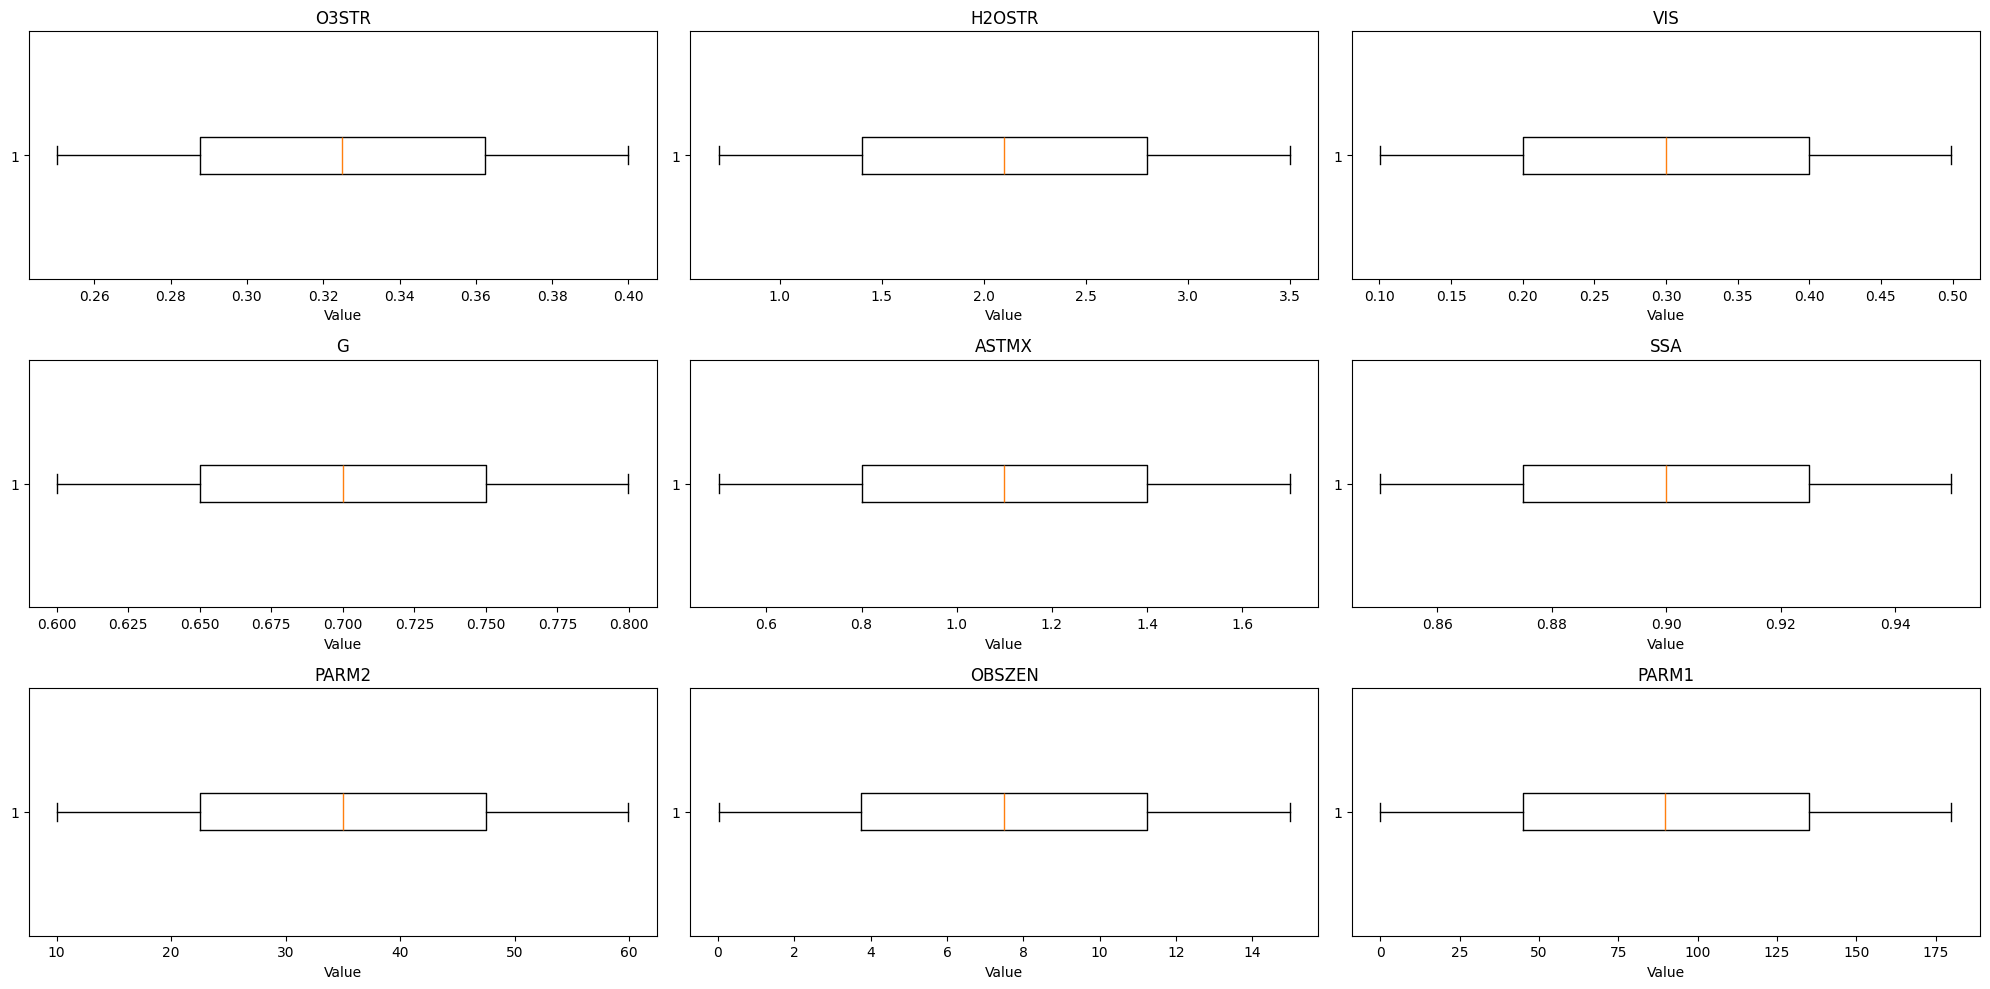

In [7]:
# detect potential outliers in the input parameters using boxplots
plt.figure(figsize=(20, 10))
for i in range(X_train.shape[1]):
    plt.subplot(3, 3, i+1)
    plt.boxplot(X_train[:, i], vert=False)
    plt.title(param_names[i])
    plt.xlabel("Value")
plt.tight_layout()
plt.show()

As expected from the distributions shown above, no outliers can be seen in the dataset.

Correlation matrix:
            O3STR    H2OSTR       VIS         G     ASTMX       SSA     PARM2    OBSZEN     PARM1
O3STR   1.000000 -0.009808  0.017317 -0.028726 -0.004428  0.003923  0.039847  0.008036 -0.044014
H2OSTR -0.009808  1.000000  0.052001 -0.076699 -0.020032  0.039859 -0.007161  0.058809  0.033224
VIS     0.017317  0.052001  1.000000 -0.017497  0.092734  0.057227  0.005658 -0.016578 -0.043741
G      -0.028726 -0.076699 -0.017497  1.000000 -0.020244  0.065476  0.044121  0.004497  0.010482
ASTMX  -0.004428 -0.020032  0.092734 -0.020244  1.000000  0.016107  0.072337 -0.026959 -0.093277
SSA     0.003923  0.039859  0.057227  0.065476  0.016107  1.000000 -0.013776  0.021112  0.047424
PARM2   0.039847 -0.007161  0.005658  0.044121  0.072337 -0.013776  1.000000  0.044679 -0.065723
OBSZEN  0.008036  0.058809 -0.016578  0.004497 -0.026959  0.021112  0.044679  1.000000 -0.036335
PARM1  -0.044014  0.033224 -0.043741  0.010482 -0.093277  0.047424 -0.065723 -0.036335  1.000000


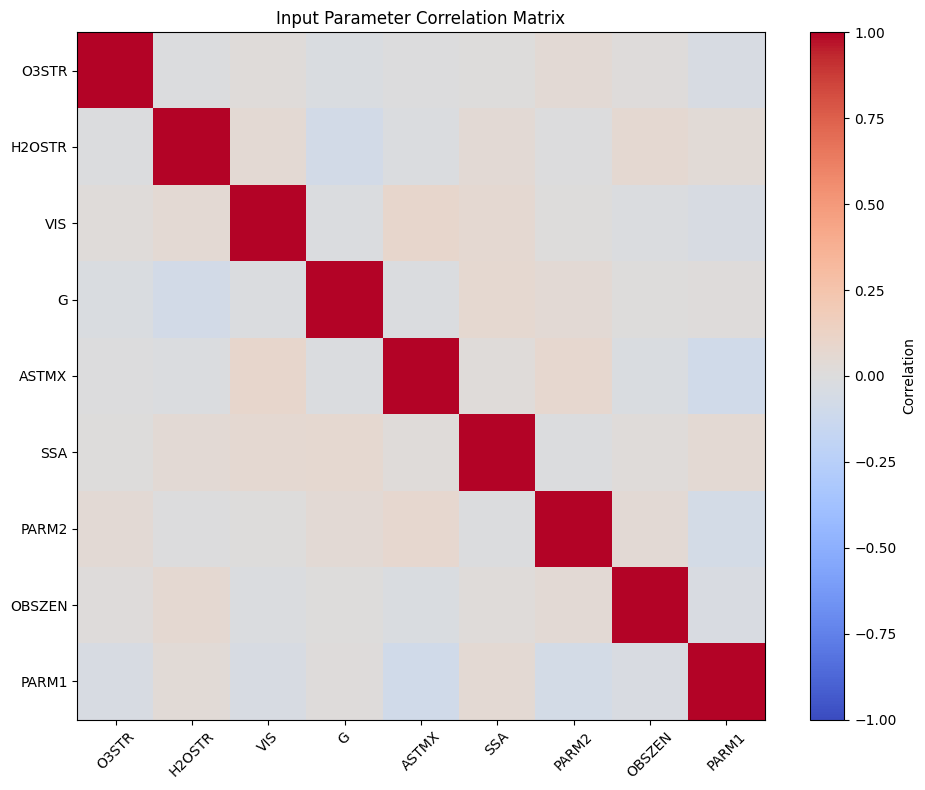

In [8]:
corr = pd.DataFrame(X_train, columns=param_names).corr()

print("Correlation matrix:\n", corr)

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(param_names)), param_names, rotation=45)
plt.yticks(range(len(param_names)), param_names)

plt.title("Input Parameter Correlation Matrix")
plt.tight_layout()
plt.show()

Correlations between different input parameters are all around 0.

In [9]:
Y_train_resh = Y_train.reshape(-1, Y_train.shape[1] // len(wavelengths), len(wavelengths))
print("Y_train reshaped:", Y_train_resh.shape)

Y_train reshaped: (500, 6, 4205)


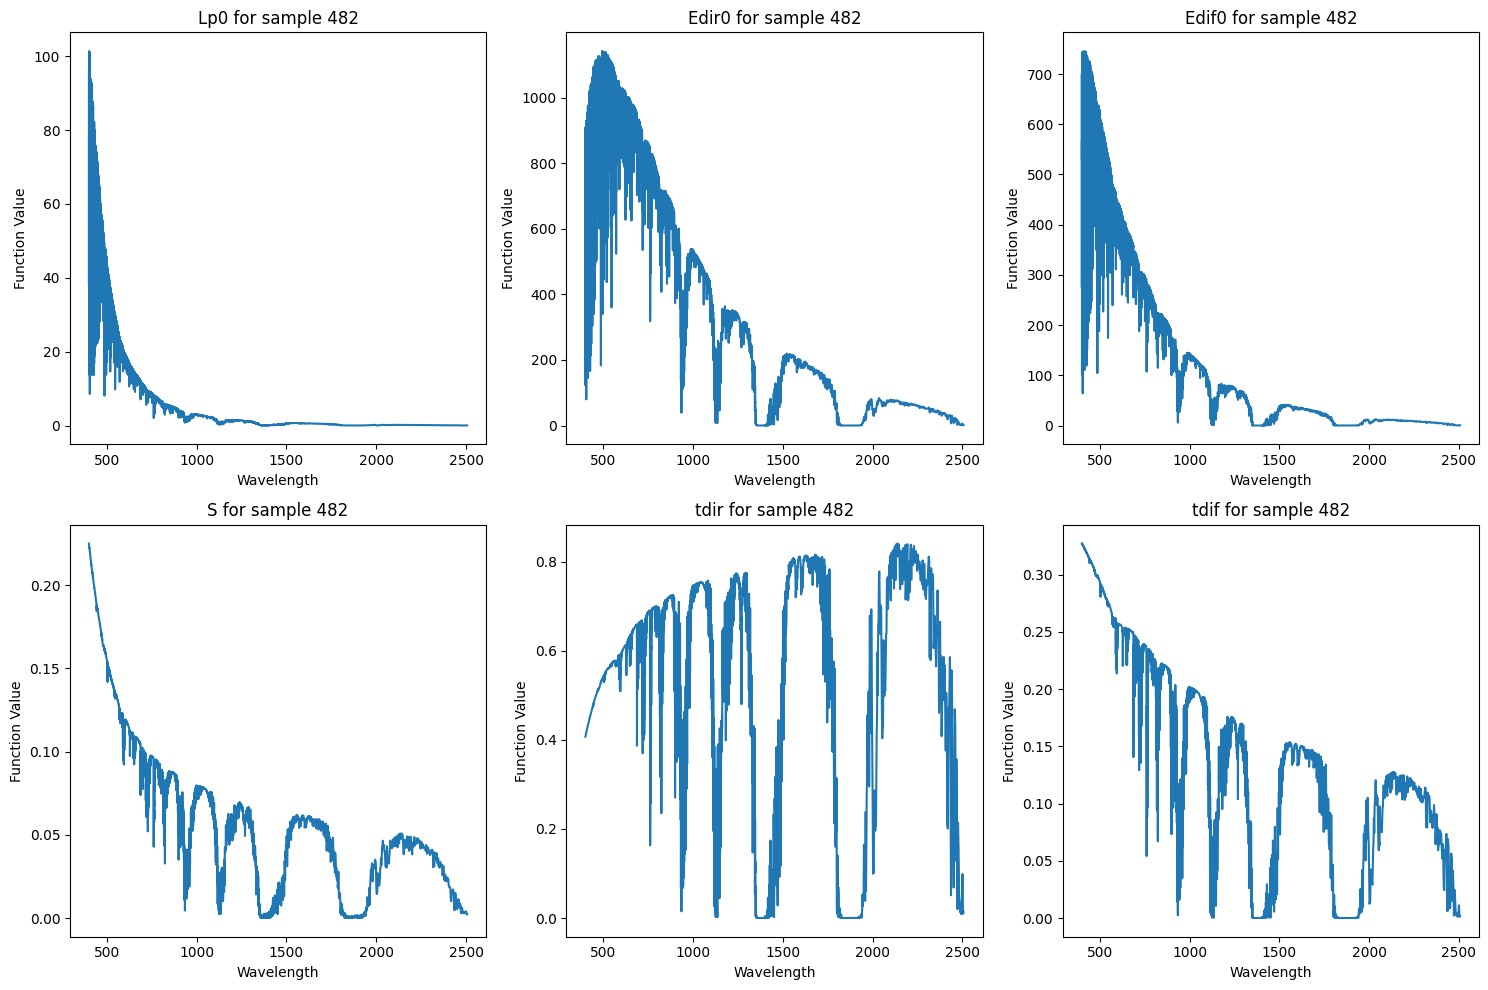

In [10]:
# visualize outputs for a random sample in different subplots
sample_idx = np.random.randint(Y_train_resh.shape[0])
plt.figure(figsize=(15, 10))
for i in range(Y_train_resh.shape[1]):
    plt.subplot(2, 3, i+1)
    plt.plot(wavelengths, Y_train_resh[sample_idx, i, :])
    plt.title(f"{function_names[i]} for sample {sample_idx}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
plt.tight_layout()
plt.show()

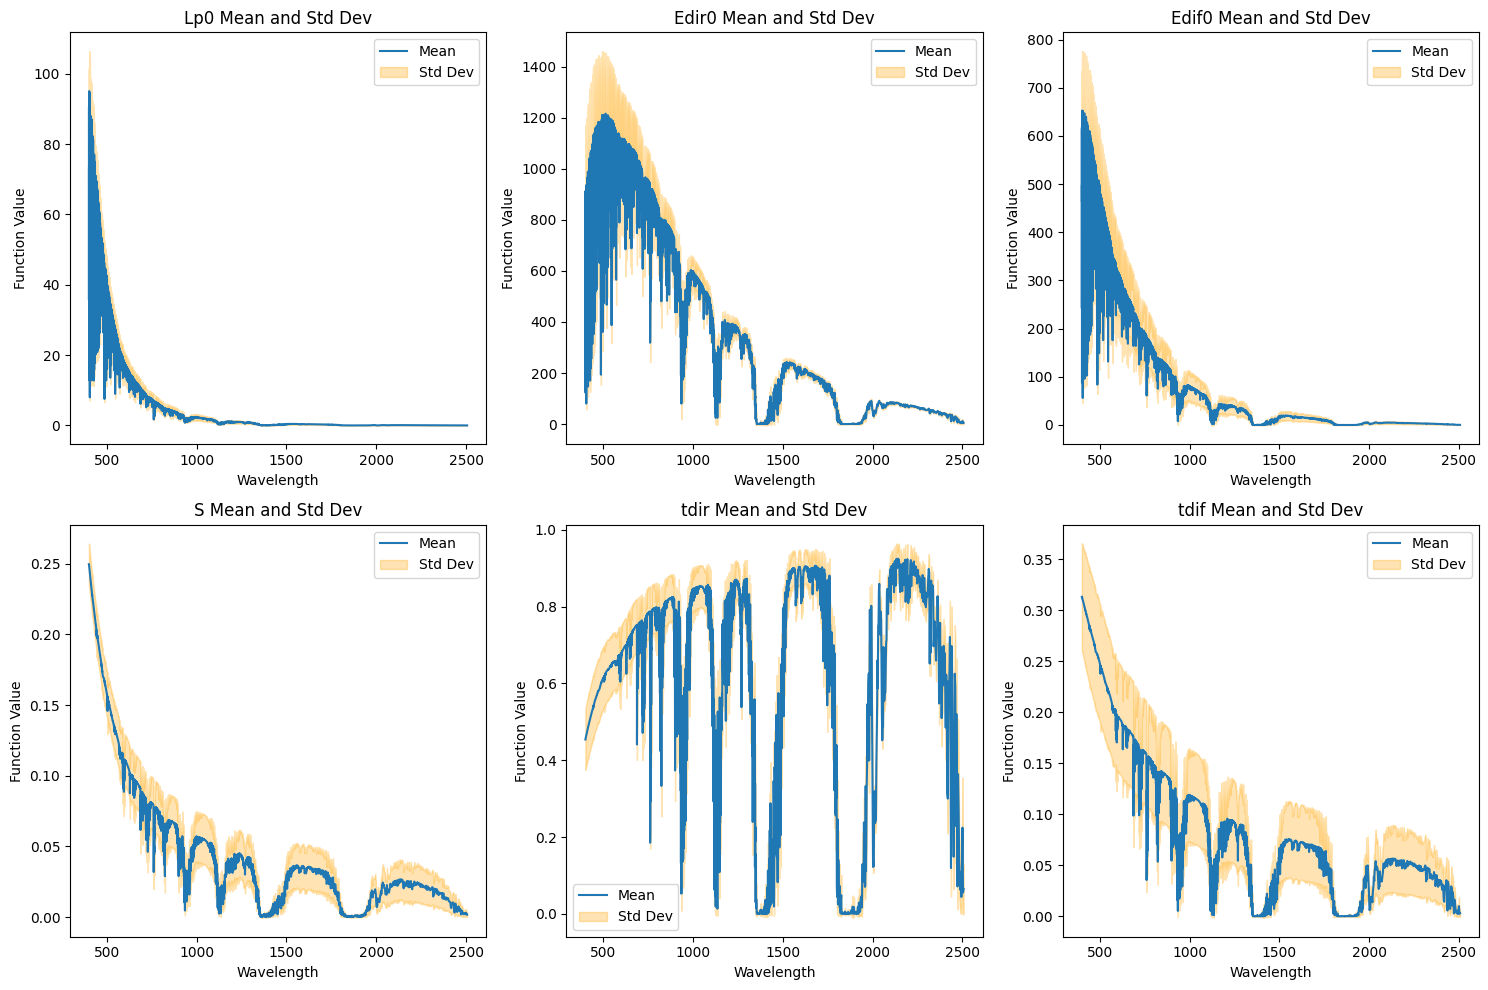

In [11]:
# visualize the mean and standard deviation band of the six functions for all outputs
plt.figure(figsize=(15, 10))
for i in range(Y_train_resh.shape[1]):
    plt.subplot(2, 3, i+1)
    mean_func = np.mean(Y_train_resh[:, i, :], axis=0)
    std_func = np.std(Y_train_resh[:, i, :], axis=0)
    plt.plot(wavelengths, mean_func, label="Mean")
    plt.fill_between(wavelengths, mean_func - std_func, mean_func + std_func, color="orange", alpha=0.3, label="Std Dev")
    plt.title(f"{function_names[i]} Mean and Std Dev")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()
plt.tight_layout()
plt.show()

Correlation between output functions:
 [[ 1.      0.4844  0.9042  0.9225 -0.2214  0.808 ]
 [ 0.4844  1.      0.6361  0.5397  0.3282  0.511 ]
 [ 0.9042  0.6361  1.      0.8989 -0.1521  0.9143]
 [ 0.9225  0.5397  0.8989  1.     -0.1033  0.9291]
 [-0.2214  0.3282 -0.1521 -0.1033  1.     -0.0617]
 [ 0.808   0.511   0.9143  0.9291 -0.0617  1.    ]]


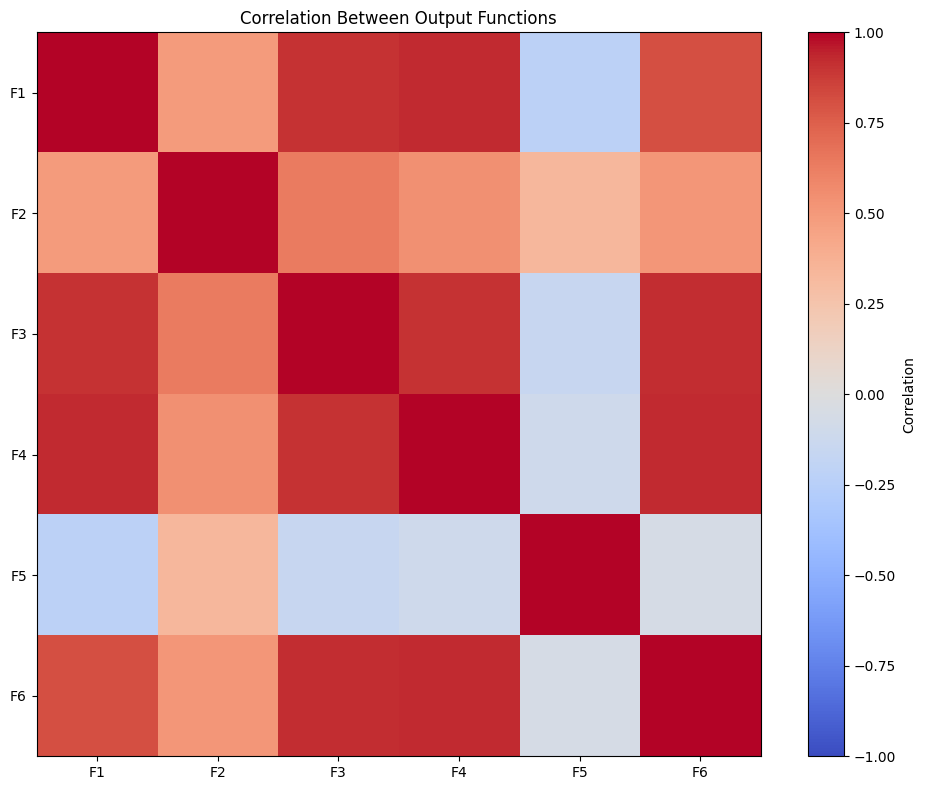

In [12]:
# explore correlation between the six output functions across all samples and wavelengths

# reshape to (6, n_samples * n_wavelengths)
Y_flat = Y_train_resh.transpose(1, 0, 2).reshape(6, -1)

corr_outputs = np.corrcoef(Y_flat)

print("Correlation between output functions:\n", corr_outputs)

plt.figure(figsize=(10, 8))
plt.imshow(corr_outputs, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(6), [f"F{i+1}" for i in range(6)])
plt.yticks(range(6), [f"F{i+1}" for i in range(6)])

plt.title("Correlation Between Output Functions")
plt.tight_layout()
plt.show()

#### Train-Val split

In [13]:
X_tr, X_val, Y_tr, Y_val = train_test_split(X_train, Y_train_resh, test_size=0.2, random_state=42)

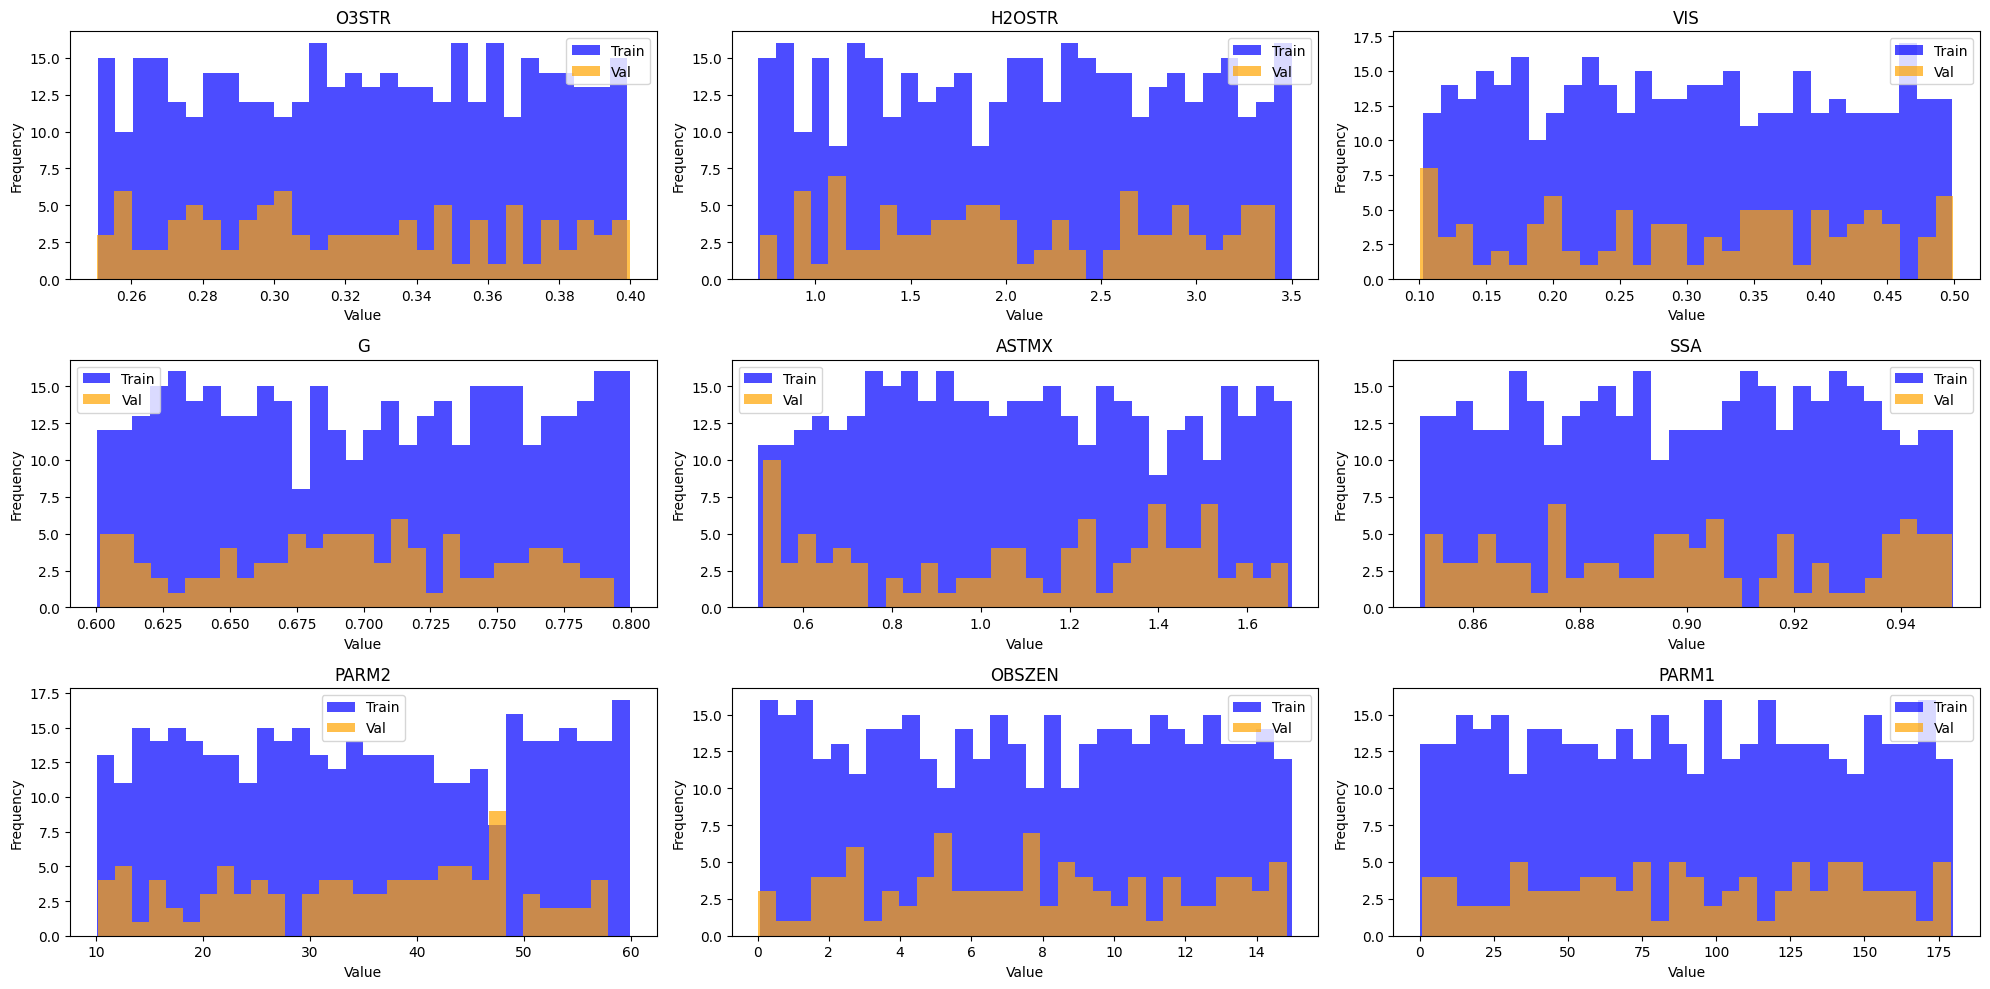

In [14]:
# overlay histograms of input train and val parameters to check if they have similar distributions
plt.figure(figsize=(20, 10))
for i in range(X_tr.shape[1]):
    plt.subplot(3, 3, i+1)
    plt.hist(X_tr[:, i], bins=30, color="blue", alpha=0.7, label="Train")
    plt.hist(X_val[:, i], bins=30, color="orange", alpha=0.7, label="Val")
    plt.title(param_names[i])
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
plt.tight_layout()
plt.show()

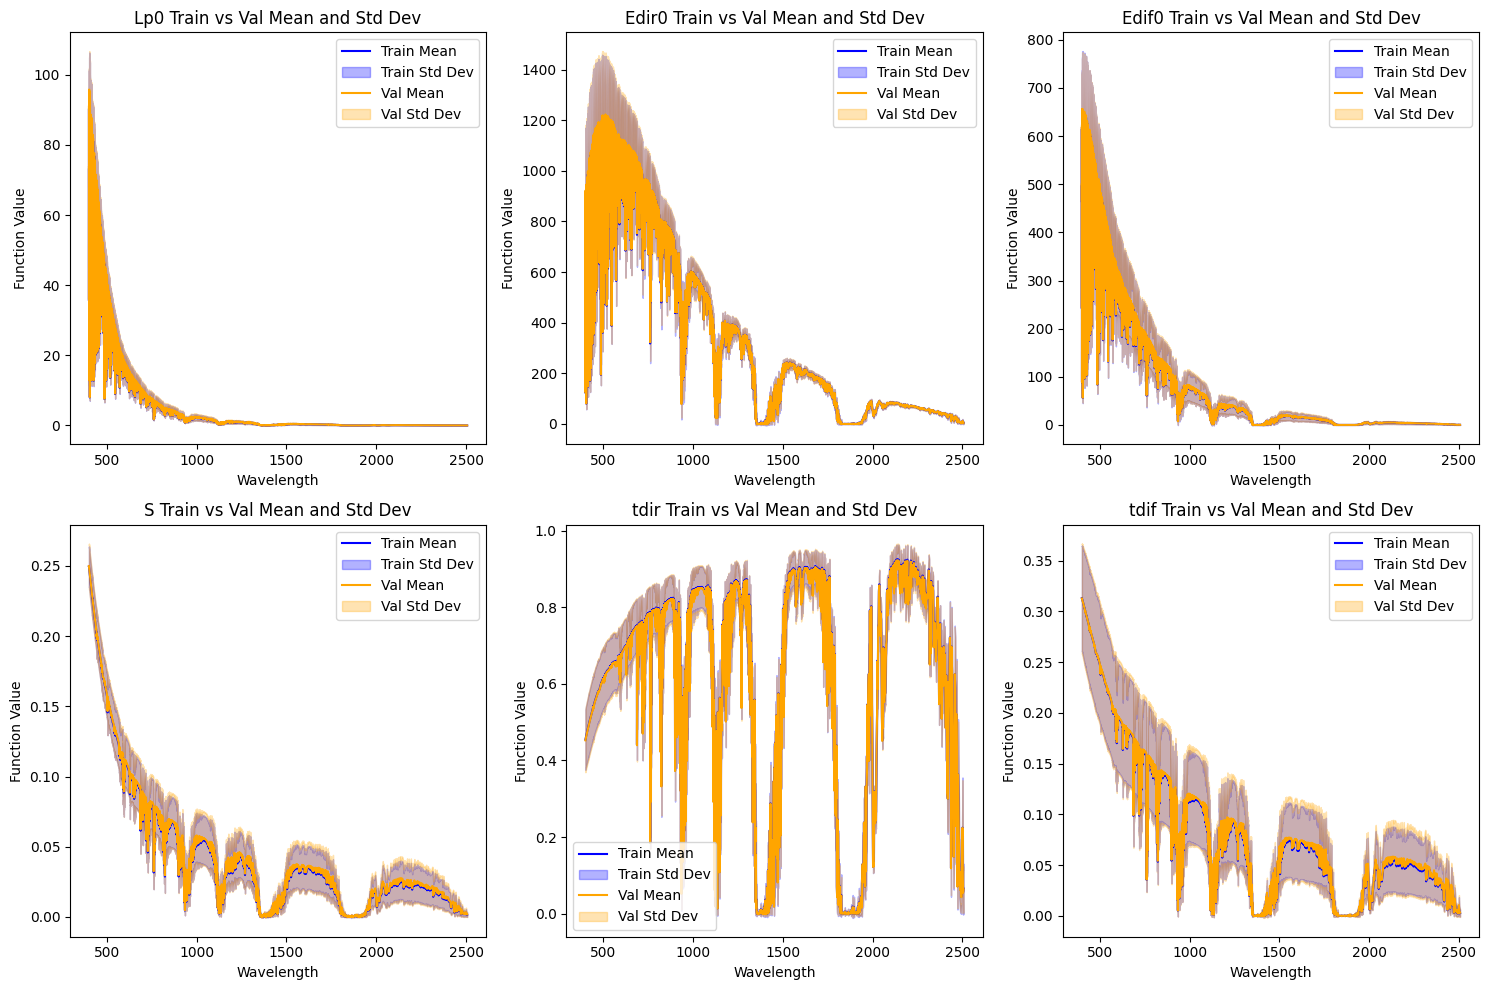

In [15]:
# overlay mean and std dev of train and val outputs to check if they have similar distributions
plt.figure(figsize=(15, 10))
for i in range(Y_tr.shape[1]):
    plt.subplot(2, 3, i+1)
    mean_tr = np.mean(Y_tr[:, i, :], axis=0)
    std_tr = np.std(Y_tr[:, i, :], axis=0)
    mean_val = np.mean(Y_val[:, i, :], axis=0)
    std_val = np.std(Y_val[:, i, :], axis=0)
    
    plt.plot(wavelengths, mean_tr, label="Train Mean", color="blue")
    plt.fill_between(wavelengths, mean_tr - std_tr, mean_tr + std_tr, color="blue", alpha=0.3, label="Train Std Dev")
    
    plt.plot(wavelengths, mean_val, label="Val Mean", color="orange")
    plt.fill_between(wavelengths, mean_val - std_val, mean_val + std_val, color="orange", alpha=0.3, label="Val Std Dev")
    
    plt.title(f"{function_names[i]} Train vs Val Mean and Std Dev")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()
plt.tight_layout()
plt.show()

#### Dimensionality Reduction

First methods: PCA and Kernel PCA.

In [16]:
def apply_pca(Y_tr, Y_val, n_components=10, kernel=False):
    """
    Apply PCA or KernelPCA to each function separately, retaining n_components components.
    - Y_tr: training outputs of shape (n_samples, n_functions, n_wavelengths)
    - Y_val: validation outputs of shape (n_samples, n_functions, n_wavelengths)
    - n_components: number of PCA components to retain
    - kernel: if True, use KernelPCA with RBF kernel; if False, use regular PCA
    - returns: list of PCA objects, list of transformed training outputs, list of transformed validation outputs
    """

    print(f"========== Applying {'KernelPCA' if kernel else 'PCA'} with n_components={n_components} to each function separately... ==========")
    pca_list = []
    Y_tr_pca_list = []
    Y_val_pca_list = []

    for i in range(Y_tr.shape[1]):
        if kernel:
            pca = KernelPCA(n_components=n_components, kernel=kernel, gamma=1e-2, fit_inverse_transform=True, alpha=0.1)
        else:
            pca = PCA(n_components=n_components)
        
        Y_tr_i = Y_tr[:, i, :] # shape of function: (n_samples, n_wavelengths)
        Y_val_i = Y_val[:, i, :]
        
        Y_tr_pca = pca.fit_transform(Y_tr_i)     # fit training here
        print(Y_tr_pca.shape)
        Y_val_pca = pca.transform(Y_val_i)       # just transform validation to avoid information leak
        
        pca_list.append(pca)
        Y_tr_pca_list.append(Y_tr_pca)
        Y_val_pca_list.append(Y_val_pca)

    # print amount of explained variance and number of components for each function
    total_explained_variance = 0

    if not kernel:
        print("  Regular PCA used, displaying results:")
        for i, pca in enumerate(pca_list):
            explained_variance = pca.explained_variance_ratio_.sum()
            total_explained_variance += explained_variance
            print(f"  Function {i+1}: Explained variance = {explained_variance:.4f}")
            print(f"  Number of components retained: {pca.n_components_}")
            print()

        print(f"  Total explained variance = {total_explained_variance:.4f}")

    print("========== PCA application completed. ==========\n")

    return pca_list, Y_tr_pca_list, Y_val_pca_list

Other method: Autoencoder.

In [17]:
class SpectralAutoencoder(nn.Module):
    def __init__(self, input_dim=4205, latent_dim=10):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        # x: (B, 4205)
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return z, x_recon


class MultiChannelAutoencoder(nn.Module):
    def __init__(self, n_channels=6, input_dim=4205, latent_dim=10):
        super().__init__()

        # one AE per radiative function
        self.aes = nn.ModuleList([ SpectralAutoencoder(input_dim, latent_dim) for _ in range(n_channels) ])

    def forward(self, x):
        """
        x: (B, 6, 4205)
        returns:
            encoded_list: list of 6 tensors (B, 10)
            decoded: (B, 6, 4205)
        """
        encoded_list = []
        decoded_list = []

        for i, ae in enumerate(self.aes):
            xi = x[:, i, :]              # (B, 4205)
            zi, xri = ae(xi)             # (B, 10), (B, 4205)

            encoded_list.append(zi)
            decoded_list.append(xri.unsqueeze(1))  # keep channel dim

        decoded = torch.cat(decoded_list, dim=1)     # (B, 6, 4205)

        return encoded_list, decoded
    
# quick test autoencoder
ae = MultiChannelAutoencoder(n_channels=6, input_dim=4205, latent_dim=10)
Y_tr_tensor = torch.tensor(Y_tr, dtype=torch.float32)  # (n_samples, 6, 4205)
encoded_list, decoded = ae(Y_tr_tensor)
print("Encoded shapes:")
for i, z in enumerate(encoded_list):
    print(f"Function {i+1}: {z.shape}")
print("Decoded shape:", decoded.shape)

Encoded shapes:
Function 1: torch.Size([400, 10])
Function 2: torch.Size([400, 10])
Function 3: torch.Size([400, 10])
Function 4: torch.Size([400, 10])
Function 5: torch.Size([400, 10])
Function 6: torch.Size([400, 10])
Decoded shape: torch.Size([400, 6, 4205])


In [ ]:
# TODO: improve training loop with train loaders, validation and early stopping, and save best model based on validation loss
# TODO: see if using validation for everything is wrong

ae = MultiChannelAutoencoder(n_channels=6, input_dim=4205, latent_dim=10).to(device)
Y_tr_tensor = torch.tensor(Y_tr, dtype=torch.float32).to(device)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).to(device)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
num_epochs = 1000
best_loss = float("inf")

for epoch in range(num_epochs):
    ae.train()

    optimizer.zero_grad()

    encoded_list, decoded = ae(Y_tr_tensor)

    loss = F.mse_loss(decoded, Y_tr_tensor)

    loss.backward()
    optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

    # save best model based on loss
    if epoch == 0 or loss.item() < best_loss:
        best_loss = loss.item()
        torch.save(ae.state_dict(), "best_autoencoder.pth")
        print(f"New best model saved with loss: {best_loss:.4f}")

Epoch: 1 Loss: 129557.0625
New best model saved with loss: 129557.0625
Epoch: 2 Loss: 104743.546875
New best model saved with loss: 104743.5469
Epoch: 3 Loss: 48630.1796875
New best model saved with loss: 48630.1797
Epoch: 4 Loss: 17653.736328125
New best model saved with loss: 17653.7363
Epoch: 5 Loss: 10078.189453125
New best model saved with loss: 10078.1895
Epoch: 6 Loss: 10316.4658203125
Epoch: 7 Loss: 8114.1005859375
New best model saved with loss: 8114.1006
Epoch: 8 Loss: 8804.251953125
Epoch: 9 Loss: 7037.45751953125
New best model saved with loss: 7037.4575
Epoch: 10 Loss: 5888.10302734375
New best model saved with loss: 5888.1030
Epoch: 11 Loss: 4992.29833984375
New best model saved with loss: 4992.2983
Epoch: 12 Loss: 3319.735107421875
New best model saved with loss: 3319.7351
Epoch: 13 Loss: 3874.295654296875
Epoch: 14 Loss: 2098.76806640625
New best model saved with loss: 2098.7681
Epoch: 15 Loss: 2580.539794921875
Epoch: 16 Loss: 1755.398193359375
New best model saved wit

In [37]:
def apply_autoencoder(Y_tr):
    ae = MultiChannelAutoencoder(n_channels=6, input_dim=Y_tr.shape[2], latent_dim=10).to(device)
    # load best autoencoder model
    if Path("best_autoencoder.pth").exists():
        ae.load_state_dict(torch.load("best_autoencoder.pth", map_location=device))
    Y_tr_tensor = torch.tensor(Y_tr, dtype=torch.float32).to(device)
    
    ae.eval()
    with torch.no_grad():
        encoded_list, _ = ae(Y_tr_tensor)
    encoded_numpy = [ z.cpu().numpy() for z in encoded_list ]
    print("Encoded representations (numpy):")
    for i, z in enumerate(encoded_numpy):
        print(f"Function {i+1}: {z.shape}")
    return encoded_numpy

#### Scaling

In [38]:
def scale_data(x_tr, x_val, y_tr_red_list, scale_type="standard"):
    """
    Scale the data using either standard scaling or min-max scaling
    - inputs: training inputs, validation inputs, list of PCA-transformed training outputs, scaling type
    - outputs: scaled training inputs, scaled validation inputs, list of scaled PCA-transformed training outputs, list of scalers used for each output function
    """
    print(f"========== Scaling data using {scale_type} scaling... ==========")
    scaler = StandardScaler() if scale_type == "standard" else MinMaxScaler()

    # standard scaling
    x_scaler = scaler.fit(x_tr)
    X_tr_scaled = x_scaler.transform(x_tr)
    X_val_scaled = x_scaler.transform(x_val)

    y_scalers = []
    Y_tr_reduced_scaled_list = []
    for i in range(len(y_tr_red_list)):
        scaler = StandardScaler() if scale_type == "standard" else MinMaxScaler()
        Y_scaled = scaler.fit_transform(y_tr_red_list[i])
        y_scalers.append(scaler)
        Y_tr_reduced_scaled_list.append(Y_scaled)

    print("========== Scaling completed. ==========\n")

    return X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled_list, y_scalers

#### Gaussian Process Regressor fit

In [ ]:
def fit_gp(X_tr_scaled, Y_tr_reduced_scaled_list):
    """
    Fit a Gaussian Process Regressor for each output function using the scaled training data
    - inputs: scaled training inputs, list of scaled PCA-transformed training outputs
    - outputs: list of fitted GaussianProcessRegressor models for each output function
    """

    print("========== Fitting Gaussian Process Regressor for each output function... ==========")

    # RBF with length_scale as a vector -> ARD kernel
    n_features = X_tr_scaled.shape[1]
    kernel = (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

    # fit Gaussian Process for each function
    gpr_list = []

    # start measuring time
    start_time = time.time()
    for i in range(len(Y_tr_reduced_scaled_list)):
        gpr = GaussianProcessRegressor(kernel=copy.deepcopy(kernel), n_restarts_optimizer=5, random_state=42)
        gpr.fit(X_tr_scaled, Y_tr_reduced_scaled_list[i])
        print("Learned kernel:", gpr.kernel_)
        gpr_list.append(gpr)
    end_time = time.time()
    print(f"Time taken to fit GPs: {end_time - start_time:.2f} seconds")

    print("========== Gaussian Process fitting completed. ==========\n")

    return gpr_list, end_time - start_time

#### Validation

In [ ]:
# TODO: improve pipeline correctness and modularity, remove globals and assert shapes and types of inputs and outputs
def validate_gp(gpr_list, X_val_scaled, y_scalers, current_pca_list):
    """
    Validate the fitted Gaussian Process models on the validation set
    - inputs: list of fitted GaussianProcessRegressor models, scaled validation inputs, list of scaled PCA-transformed validation outputs, list of scalers used for each output function, list of PCA objects for each output function
    - outputs: numpy array of predicted outputs on the validation set in the original space (n_samples, 6, 4205)
    """

    print("========== Validating Gaussian Process models on the validation set... ==========")

    # predictions on validation set
    Y_val_pred_reduced_scaled_list = []
    for i in range(len(gpr_list)):
        Y_pred_scaled = gpr_list[i].predict(X_val_scaled)
        Y_val_pred_reduced_scaled_list.append(Y_pred_scaled)

    # inverse transform predictions to original scale
    Y_val_pred_reduced_list = []
    for i in range(len(gpr_list)):
        Y_pred = y_scalers[i].inverse_transform(Y_val_pred_reduced_scaled_list[i])
        Y_val_pred_reduced_list.append(Y_pred)

    # inverse transform predictions to original space
    Y_val_pred_list = []
    if current_pca_list is not None:
        for i in range(len(gpr_list)):
            Y_pred = current_pca_list[i].inverse_transform(Y_val_pred_reduced_list[i])
            Y_val_pred_list.append(Y_pred)
    else:
        # TODO: apply autoencoder decoder to get back to original space
        print()
        # # convert to tensor and apply autoencoder decoder
        # Y_val_pred_reduced_tensor_list = [ torch.tensor(Y_val_pred_reduced_list[i], dtype=torch.float32).to(device) for i in range(len(gpr_list)) ]
        # ae = MultiChannelAutoencoder(n_channels=6, input_dim=Y_tr.shape[2], latent_dim=10).to(device)
        # # load best autoencoder model
        # if Path("best_autoencoder.pth").exists():
        #     ae.load_state_dict(torch.load("best_autoencoder.pth", map_location=device))
        #     ae.eval()
        #     with torch.no_grad():
        #         _, decoded = ae(Y_val_pred_reduced_tensor_list[0]) # just pass one of the functions since they all share the same decoder
        #     Y_val_pred_list = decoded.cpu().numpy()

    Y_val_pred = np.stack(Y_val_pred_list, axis=1)  # (n_samples, 6, 4205)
    print("Y_val_pred shape:", Y_val_pred.shape)
    print("NaN values in Y_val_pred:", np.isnan(Y_val_pred).sum())

    # MRE calculation
    eps = 1e-8 # lower values of epsilon lead to very high MRE due to division by small numbers, higher values get more stable MRE estimates
    # wavelengths to exclude from MRE calculation: 931-945 nm, 1100-1160 nm, 1300-1500 nm, 1750-1980 nm, and >2420 nm
    mask = (
        ((wavelengths < 931) | (wavelengths > 945)) &
        ((wavelengths < 1100) | (wavelengths > 1160)) &
        ((wavelengths < 1300) | (wavelengths > 1500)) &
        ((wavelengths < 1750) | (wavelengths > 1980)) &
        (wavelengths < 2420)
    )

    mre = np.mean(
        np.abs(Y_val_pred[:, :, mask] - Y_val[:, :, mask]) /
        (np.abs(Y_val[:, :, mask]) + eps)
    )
    print(f"----- Validation MRE: {mre} -----")

    print("========== Validation completed. ==========\n")

    return Y_val_pred, mre

Apply the whole pipeline.

In [41]:
def gp_pipeline(X_tr, X_val, Y_tr, Y_val, param_grid):
    """
    Run the entire Gaussian Process pipeline with hyperparameter tuning
    - inputs: training inputs, validation inputs, training outputs, validation outputs, hyperparameter grid (dictionary with keys "kernel" and "scale_type")
    - outputs: best predicted validation outputs in original space, best MRE achieved on the validation set
    """

    # read gp_results.csv to get the last id used for logging results
    if Path("gp_results.csv").exists():
        results_df = pd.read_csv("gp_results.csv")
        last_id = results_df["id"].max()
        if last_id is np.nan:
            last_id = 1
    else:
        last_id = 1

    best_mre = float("inf")
    best_Y_val_pred = None
    for dimred_method in param_grid["dimred_method"]:
        for scale_type in param_grid["scale_type"]:
            start_time = time.time()
            print(f"========== Running GP pipeline with dimred_method={dimred_method} and scale_type={scale_type}... ==========")

            # dimensionality reduction
            pca_list = None
            if dimred_method == "autoencoder":
                Y_tr_red_list = apply_autoencoder(Y_tr)
            else:
                pca_list, Y_tr_red_list, Y_val_pca_list = apply_pca(Y_tr, Y_val, n_components=10, kernel=dimred_method)

            # scaling
            X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled_list, y_scalers = scale_data(X_tr, X_val, Y_tr_red_list, scale_type=scale_type)

            # fit Gaussian Process
            gpr_list, fit_time = fit_gp(X_tr_scaled, Y_tr_reduced_scaled_list)

            # validate Gaussian Process
            Y_val_pred, mre = validate_gp(gpr_list, X_val_scaled, y_scalers, pca_list)

            # save best model based on MRE
            if mre < best_mre:
                best_mre = mre
                best_Y_val_pred = Y_val_pred
                print(f"New best MRE: {best_mre} with dimred_method={dimred_method} and scale_type={scale_type}")

            end_time = time.time()

            # write parameters and MRE to csv file
            results_df = pd.DataFrame({
                "id": [last_id],
                "dimred_method": [dimred_method],
                "scale_type": [scale_type],
                "fit_time": [fit_time],
                "total_time": [end_time - start_time],
                "mre": [mre]
            })
            results_df.to_csv("gp_results.csv", mode="a", header=not Path("gp_results.csv").exists(), index=False)
            last_id += 1

    return best_Y_val_pred, best_mre

param_grid = {
    "dimred_method": [False, "rbf", "sigmoid", "cosine", "autoencoder"],
    "scale_type": ["standard", "minmax"]
}
param_grid = { "dimred_method": ["autoencoder"], "scale_type": ["minmax"] } # for quick testing

Y_val_pred, best_mre = gp_pipeline(X_tr, X_val, Y_tr, Y_val, param_grid)

========== Running GP pipeline with dimred_method=autoencoder and scale_type=minmax... ==========
Encoded representations (numpy):
Function 1: (400, 10)
Function 2: (400, 10)
Function 3: (400, 10)
Function 4: (400, 10)
Function 5: (400, 10)
Function 6: (400, 10)
========== Scaling data using minmax scaling... ==========
========== Scaling completed. ==========

========== Fitting Gaussian Process Regressor for each output function... ==========


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.04**2 * RBF(length_scale=[82.8, 86.4, 1.61, 2.92, 4.7, 10.8, 1.35, 3.41, 1.23]) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

Learned kernel: 0.685**2 * RBF(length_scale=[118, 1.2, 1.17, 1e+03, 2.7, 1e+03, 0.76, 328, 324]) + WhiteKernel(noise_level=1e-05)


...

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better valu

Learned kernel: 1.12**2 * RBF(length_scale=[223, 0.793, 2.05, 1e+03, 3.25, 1e+03, 1e+03, 8.88, 1e+03]) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

Learned kernel: 1.2**2 * RBF(length_scale=[222, 7.96, 1.36, 17.5, 1.02, 14.1, 1e+03, 12.1, 1e+03]) + WhiteKernel(noise_level=1e-05)
Time taken to fit GPs: 70.77 seconds
========== Gaussian Process fitting completed. ==========

========== Validating Gaussian Process models on the validation set... ==========


IndexError: too many indices for tensor of dimension 2

Validation MRE: 0.0029144169855353963
Function 1 MRE: 0.0069
Function 2 MRE: 0.0020
Function 3 MRE: 0.0026
Function 4 MRE: 0.0030
Function 5 MRE: 0.0002
Function 6 MRE: 0.0029


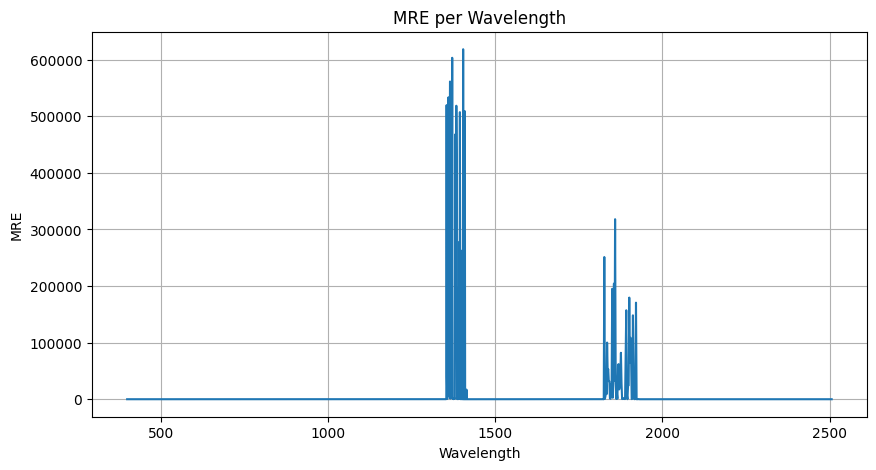

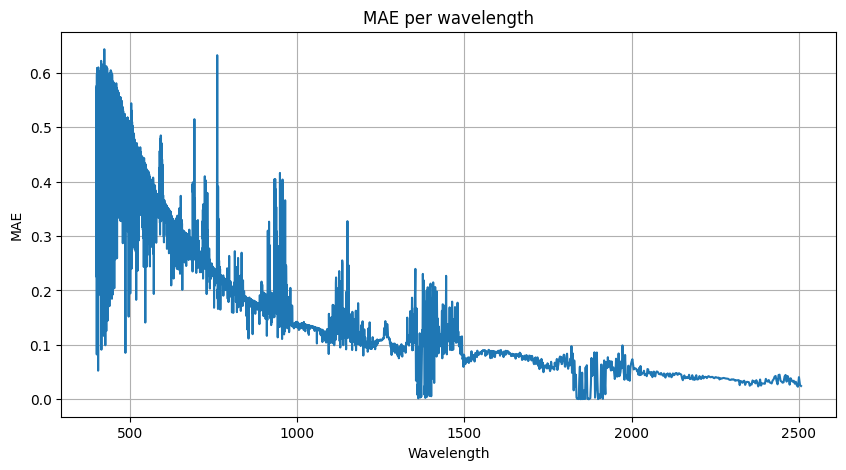

In [22]:
# MRE calculation
eps = 1e-8 # lower values of epsilon lead to very high MRE due to division by small numbers, higher values get more stable MRE estimates

# wavelengths to exclude from MRE calculation: 931-945 nm, 1100-1160 nm, 1300-1500 nm, 1750-1980 nm, and >2420 nm
mask = (
    ((wavelengths < 931) | (wavelengths > 945)) &
    ((wavelengths < 1100) | (wavelengths > 1160)) &
    ((wavelengths < 1300) | (wavelengths > 1500)) &
    ((wavelengths < 1750) | (wavelengths > 1980)) &
    (wavelengths < 2420)
)

mre = np.mean(
    np.abs(Y_val_pred[:, :, mask] - Y_val[:, :, mask]) /
    (np.abs(Y_val[:, :, mask]) + eps)
)
print("Validation MRE:", mre)

mre_per_func = np.mean(
    np.abs(Y_val_pred[:, :, mask] - Y_val[:, :, mask]) /
    (np.abs(Y_val[:, :, mask]) + eps),
    axis=(0, 2)
)
for i in range(Y_tr.shape[1]):
    print(f"Function {i+1} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = np.mean(
    np.abs(Y_val_pred - Y_val) /
    (np.abs(Y_val) + eps),
    axis=(0, 1)
)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mre_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MRE")
plt.title("MRE per Wavelength")
plt.grid()
plt.show()

mae_per_wvl = np.mean(
    np.abs(Y_val_pred - Y_val),
    axis=(0, 1)
)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

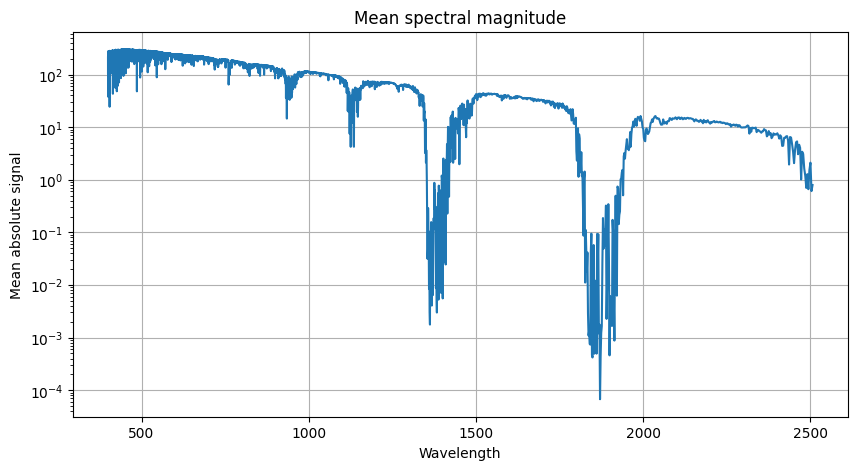

In [217]:
mean_spectrum = np.mean(np.abs(Y_val), axis=(0, 1))

plt.figure(figsize=(10,5))
plt.plot(wavelengths, mean_spectrum)
plt.yscale("log")
plt.xlabel("Wavelength")
plt.ylabel("Mean absolute signal")
plt.title("Mean spectral magnitude")
plt.grid()
plt.show()

Deep valleys at around 1400 and 1800-1900 nanometers, where the MRE spikes to high values.

MRE for sample 87: 0.0012
Function 1 MRE for sample 87: 0.0008
Function 2 MRE for sample 87: 0.0008
Function 3 MRE for sample 87: 0.0008
Function 4 MRE for sample 87: 0.0008
Function 5 MRE for sample 87: 0.0008
Function 6 MRE for sample 87: 0.0008


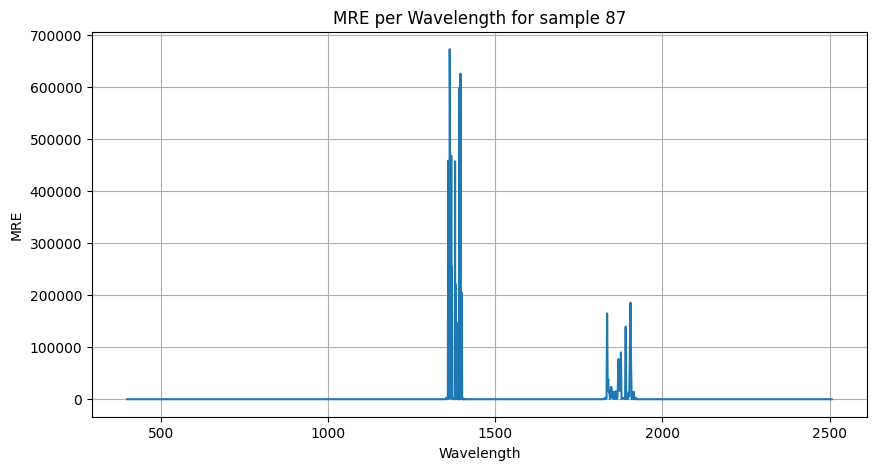

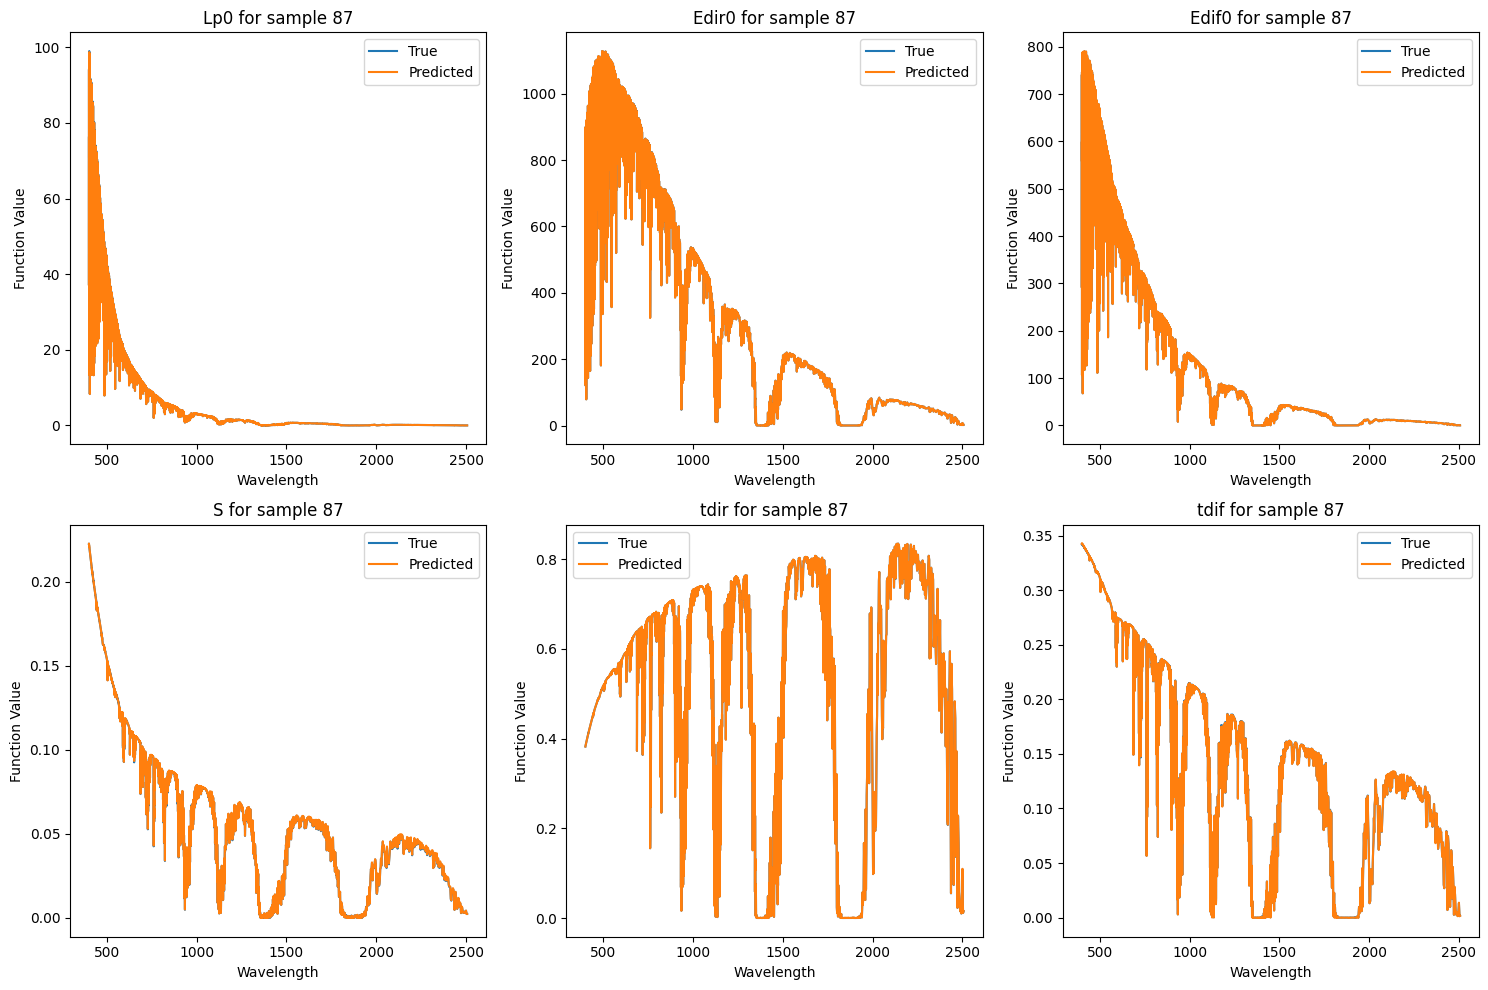

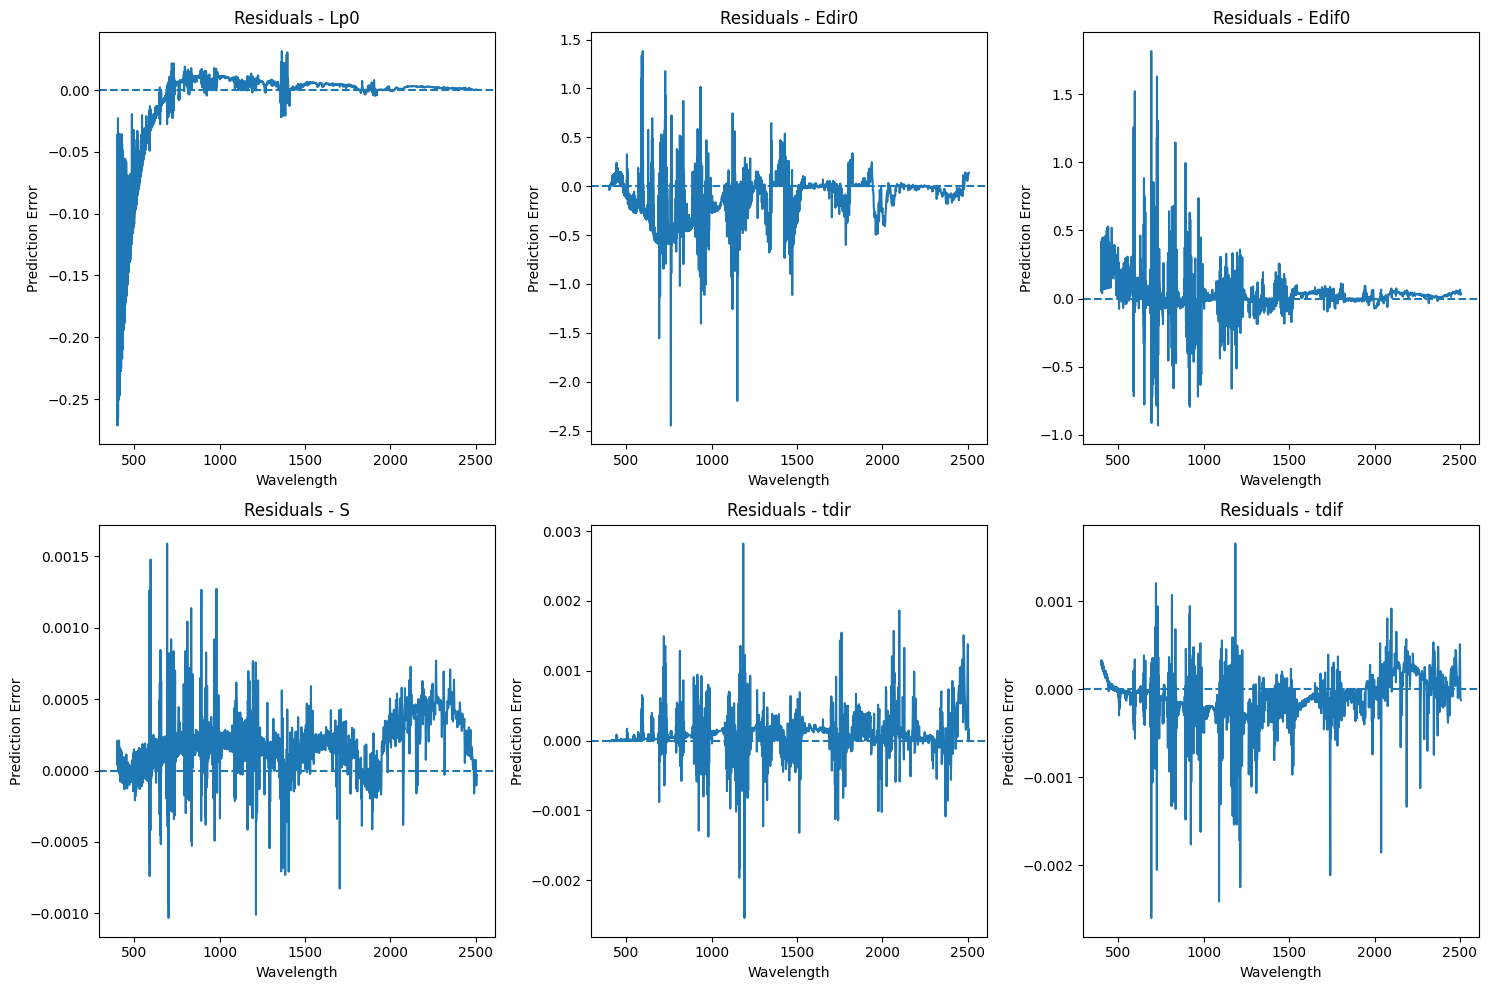

In [219]:
# predict functions for a random sample in validation set and calculate MRE for that sample
sample_idx = np.random.randint(Y_val.shape[0])

# calculate MRE for the selected sample with masking
mre_sample = np.mean(
    np.abs(Y_val_pred[sample_idx, :, mask] - Y_val[sample_idx, :, mask]) /
    (np.abs(Y_val[sample_idx, :, mask]) + eps)
)
print(f"MRE for sample {sample_idx}: {mre_sample:.4f}")

# calculate MRE for each function for the selected sample
mre_sample_per_func = np.mean(
    np.abs(Y_val_pred[sample_idx, :, mask] - Y_val[sample_idx, :, mask]) /
    (np.abs(Y_val[sample_idx, :, mask]) + eps),
    axis=1
)
for i in range(Y_val.shape[1]):
    print(f"Function {i+1} MRE for sample {sample_idx}: {mre_sample_per_func[i]:.4f}")

# calculate MRE for each wavelength for the selected sample
mre_sample_per_wvl = np.mean(
    np.abs(Y_val_pred[sample_idx] - Y_val[sample_idx]) /
    (np.abs(Y_val[sample_idx]) + eps),
    axis=0
)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mre_sample_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MRE")
plt.title(f"MRE per Wavelength for sample {sample_idx}")
plt.grid()
plt.show()

# visualize true vs predicted functions for the selected sample
plt.figure(figsize=(15, 10))
for i in range(Y_val.shape[1]):
    plt.subplot(2, 3, i+1)
    plt.plot(wavelengths, Y_val[sample_idx, i, :], label="True")
    plt.plot(wavelengths, Y_val_pred[sample_idx, i, :], label="Predicted")
    plt.title(f"{function_names[i]} for sample {sample_idx}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))

# residuals plot for the selected sample
for i in range(Y_val.shape[1]):
    plt.subplot(2, 3, i+1)

    residual = Y_val_pred[sample_idx, i] - Y_val[sample_idx, i]

    plt.plot(wavelengths, residual)
    plt.axhline(0, linestyle="--")

    plt.title(f"Residuals - {function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()